# **EDA of WhatsApp Integrity Data**

In [46]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [47]:
df = pd.read_csv('data/data.csv')
df.drop(columns=["label"], inplace=True)
df.head(3)

,sender_phone,is_business,spam_report_count,about_text,is_verified_biz,body
0,9.230000e+11,1,157,Lucky Draw Verification,0,"You won Rs.50,000! Claim here http://reward.xyz"
1,9.230000e+11,1,198,Bank Helpdesk,0,Your account is locked. Verify now at http://s...
2,9.230000e+11,1,0,Busy,1,"Hey, check the lab assignment details on the p..."


- **categorical**:is_business, is_verified_biz
  
- **numeric**:spam_report_count
  
- **mixed**:sender_phone, about_text, body

In [48]:
df.shape

(1890, 6)

In [49]:
df.isnull().sum()

sender_phone         0
is_business          0
spam_report_count    0
about_text           0
is_verified_biz      0
body                 0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.drop_duplicates(inplace=True)

In [52]:
df.shape

(1890, 6)

## Univariate Analysis

In [53]:
print ("Business accounts: ", df['is_business'].sum(),"and Non-Business accounts: ", len(df)-df['is_business'].sum())
print ("Verified Business accounts: ", df['is_verified_biz'].sum(),"and Non-Verified Business accounts: ", len(df)-df['is_verified_biz'].sum())

Business accounts:  845 and Non-Business accounts:  1045
Verified Business accounts:  204 and Non-Verified Business accounts:  1686


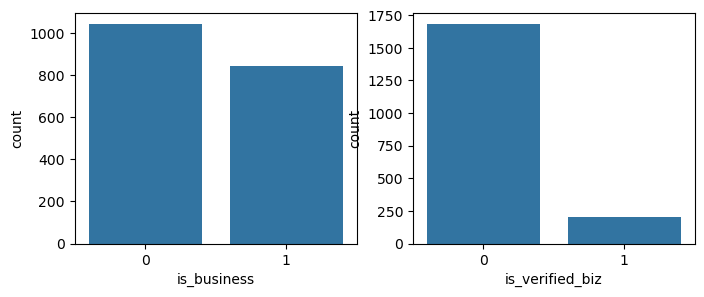

In [54]:
plt.figure(figsize=(8, 3)) 

plt.subplot(1, 2, 1)
sns.countplot(x='is_business', data=df)

plt.subplot(1, 2, 2)
sns.countplot(x='is_verified_biz', data=df)


plt.show()

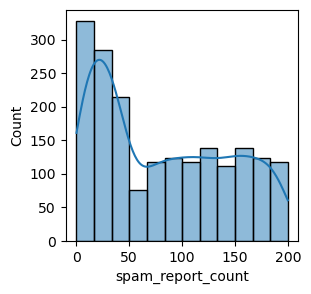

In [55]:
plt.figure(figsize=(3, 3))
sns.histplot(data=df, x="spam_report_count", kde=True)
plt.show()


## Feature Engineering

In [56]:
import re
# YE BANAO — model ke liye features
def create_features(row):
    text = row['body'].lower() if isinstance(row['body'], str) else ''
    
    has_url = 1 if re.search(r'(https?://|www\.)\S+', text) else 0
    has_shortener = 1 if any(s in text for s in ['bit.ly','tinyurl','t.co','ow.ly']) else 0
    has_urgency = 1 if any(w in text for w in ['urgent','immediately','now','final notice','suspended','disconnected','unpaid']) else 0
    has_action_words = 1 if any(w in text for w in ['pay','claim','fund','login','verify','account']) else 0
    
    return pd.Series([has_url, has_shortener, has_urgency, has_action_words])

df[['has_url','has_shortener','has_urgency','has_action_words']] = df.apply(create_features, axis=1)
df.sample(5)

,sender_phone,is_business,spam_report_count,about_text,is_verified_biz,body,has_url,has_shortener,has_urgency,has_action_words
1166,9.194007e+09,0,175,Bank Helpdesk,0,"You have won Rs.50,000! Claim your prize at ht...",1,0,0,1
884,2.544909e+09,1,92,Free Gift Claim,0,Your account is suspended. Login to verify and...,1,0,1,1
314,2.548245e+09,0,44,Office Updates,0,Annual performance reviews start from Thursday...,0,0,0,0
624,2.341688e+09,0,191,Scholarship Fund,0,"Job offer: Rs.1,00,000/month salary. Login and...",1,1,1,1
608,8.801285e+10,0,27,Real Estate Agent,0,Class test for Math postponed to Tuesday. Stud...,0,0,0,0


In [57]:
def create_label(row):
    score = 0

    # Spam count — strong real world signal
    if row['spam_report_count'] > 150:   score += 3
    elif row['spam_report_count'] > 100: score += 2
    elif row['spam_report_count'] > 50:  score += 1

    # Unverified business — suspicious
    if row['is_business'] == 1 and row['is_verified_biz'] == 0:
        score += 2

    risk_level = min(score, 5)
    return pd.Series([risk_level, 1 if risk_level >= 3 else 0])

df[['risk_level', 'is_suspicious']] = df.apply(create_label, axis=1)
df.sample(3)

,sender_phone,is_business,spam_report_count,about_text,is_verified_biz,body,has_url,has_shortener,has_urgency,has_action_words,risk_level,is_suspicious
659,2.545621e+09,1,40,Online Shop,0,Can you pick up charger from the office supply...,0,0,0,0,2,0
569,8.801120e+10,1,136,Govt Grant Office,0,Scholarship alert! Rs.500 fund approved. Submi...,1,1,0,1,4,1
274,2.542291e+09,1,119,Prize Claim Center,0,"Rs.50,000 has been credited to your fund. Veri...",1,0,0,1,4,1


In [58]:
df.value_counts('risk_level')

risk_level
0    677
3    352
2    306
5    222
4    217
1    116
Name: count, dtype: int64

In [59]:
df.has_url.value_counts()

has_url
1    1062
0     828
Name: count, dtype: int64

In [60]:
df.is_suspicious.value_counts()

is_suspicious
0    1099
1     791
Name: count, dtype: int64

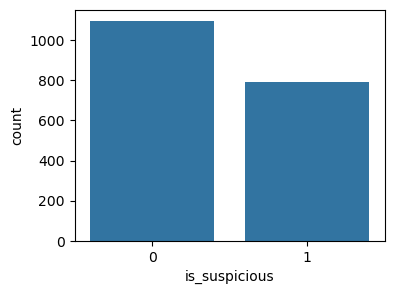

In [61]:
plt.figure(figsize=(4, 3)) 
sns.countplot(data=df, x="is_suspicious")
plt.show()

## Multivariate Analysis

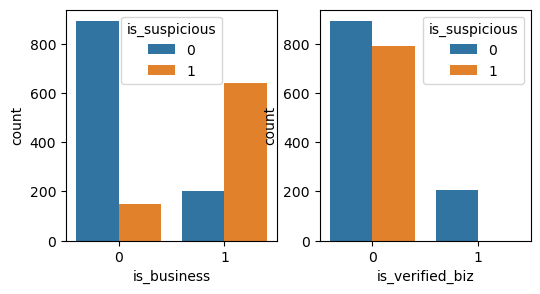

In [62]:
plt.figure(figsize=(6, 3)) 

plt.subplot(1, 2, 1)
sns.countplot(x='is_business', data=df, hue="is_suspicious")

plt.subplot(1, 2, 2)
sns.countplot(x='is_verified_biz', data=df, hue="is_suspicious")

plt.show()

- Spam accounts are irrespective of their business status.
- Verified accounts are 100% safe while non verified accounts are less safe.

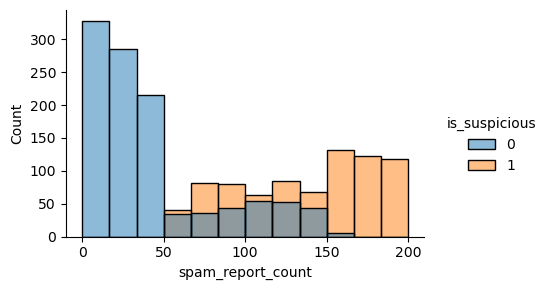

In [63]:
sns.displot(data=df, x="spam_report_count", hue="is_suspicious", height=3, aspect=1.5)

- Numbers with more spam report count are phishing numbers